<a href="https://colab.research.google.com/github/sathasivamn/Self-Project---Gold-Prediction/blob/main/Project_Gold_Price_Prediction_using_GBRT_and_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gold Price Prediction using GBRT and XGBoost

In [1]:
#1: Install Required Libraries
!pip install xgboost

In [2]:
#2: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

#  Explanation:
## GradientBoostingRegressor is GBRT from sklearn.
## XGBRegressor is the XGBoost implementation.
## Metrics are used for evaluation.

In [4]:
#3: Load the Dataset
# Load the dataset
df = pd.read_csv('gold_data.csv')

# Show first few rows
df.head()

,Date,Price,Open,High,Low,Volume
0,29/09/2015,1127.1,1132.4,1133.6,1123.9,0.25
1,30/09/2015,1115.5,1127.5,1127.5,1111.3,0.28
2,01/10/2015,1114.0,1114.9,1118.3,1111.0,0.26
3,02/10/2015,1136.7,1113.0,1140.7,1105.0,0.47
4,05/10/2015,1137.7,1138.7,1141.3,1129.8,0.20


In [6]:
# 4: Data Preprocessing
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Summary statistics
df.describe()

Missing values:
 Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
dtype: int64


,Price,Open,High,Low,Volume
count,1804.000000,1804.000000,1804.000000,1804.000000,1804.000000
mean,1480.877644,1478.720355,1487.743110,1469.452300,93.260327
std,276.132747,273.356556,275.498167,270.560201,137.485763
min,1049.700000,1051.100000,1062.700000,1045.700000,0.000000
25%,1257.225000,1257.675000,1264.975000,1251.675000,0.580000
50%,1334.600000,1334.700000,1341.750000,1326.850000,1.895000
75%,1787.750000,1783.250000,1791.050000,1774.425000,205.345000
max,2054.600000,2062.400000,2085.200000,2033.600000,816.530000


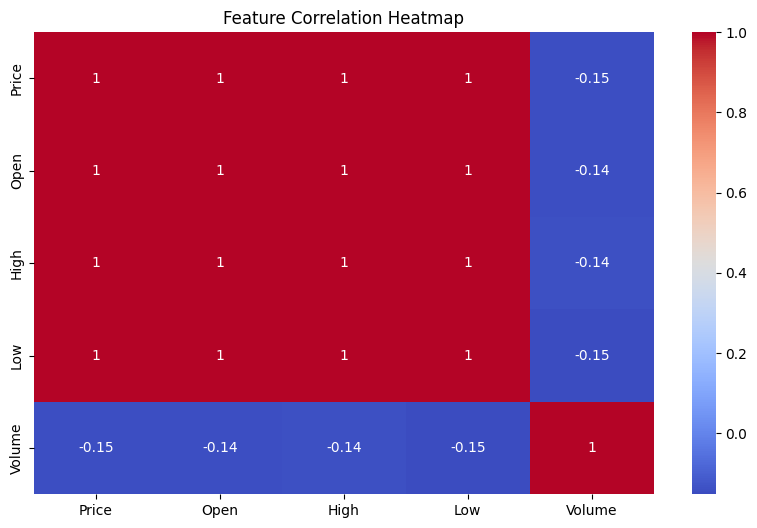

In [8]:
#5: Correlation Heatmap
# Plot correlation heatmap
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')  # Assuming 'dd/mm/yyyy' format

# Extract numerical features for correlation analysis
numerical_features = df.select_dtypes(include=['number'])

# Visualize correlation matrix for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
#6: Split Data into Features and Target
# Assume the target is 'GLD' (Gold Price) — update if different
X = df.drop(['Price', 'Date'], axis=1)  # Dropping 'Date' column
y = df['Price']  # Changed 'GLD' to 'Price'

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#7: Train GBRT Model
# Train Gradient Boosted Regression Trees model
gbrt_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbrt_model.fit(X_train, y_train)

# Predict
gbrt_pred = gbrt_model.predict(X_test)

In [11]:
# Evaluate
print("GBRT Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, gbrt_pred))
print("R² Score:", r2_score(y_test, gbrt_pred))

GBRT Performance:
Mean Squared Error: 95.50443580468907
R² Score: 0.9988221190244515


In [13]:
#8: Train XGBoost Model
# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

In [14]:
# Evaluate
print("XGBoost Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, xgb_pred))
print("R² Score:", r2_score(y_test, xgb_pred))

XGBoost Performance:
Mean Squared Error: 96.72130588695849
R² Score: 0.9988071110501355


In [15]:
#9: Predict Future Price Example
# Use one test sample to simulate a future prediction
example = X_test.iloc[0].values.reshape(1, -1)

gbrt_future = gbrt_model.predict(example)[0]
xgb_future = xgb_model.predict(example)[0]

print(f"Future Gold Price Prediction (GBRT): {gbrt_future:.2f}")
print(f"Future Gold Price Prediction (XGBoost): {xgb_future:.2f}")

Future Gold Price Prediction (GBRT): 1824.81
Future Gold Price Prediction (XGBoost): 1826.02


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


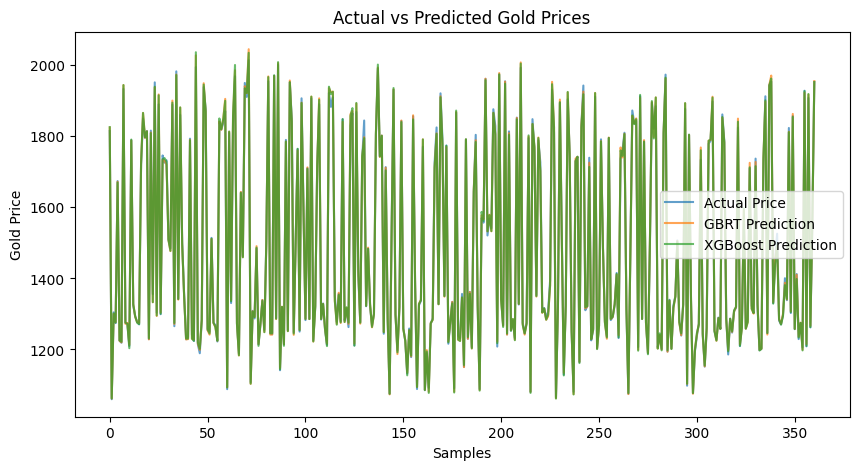

In [16]:
#10: Compare Model Predictions (Optional)
# Compare predictions visually
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price', alpha=0.7)
plt.plot(gbrt_pred, label='GBRT Prediction', alpha=0.7)
plt.plot(xgb_pred, label='XGBoost Prediction', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Gold Prices')
plt.xlabel('Samples')
plt.ylabel('Gold Price')
plt.show()